# Spike Codec Compression Benchmark

**SC-NeuroCore v3.14** — 5 codecs compared on synthetic spike trains.

Neural data compression is critical for brain-computer interfaces,
neuromorphic chip-to-chip communication, and high-density neural
probes (Neuropixels: 384 channels × 30 kHz).

SC-NeuroCore provides 5 spike codecs:

| Codec | Principle | Best for |
|-------|-----------|----------|
| ISI | Inter-spike interval encoding | Regular spikers |
| AER | Address-event representation | Multi-channel sparse |
| Predictive | EMA prediction + residual | Stationary rates |
| Delta | Spatial delta coding | Correlated channels |
| Streaming | Online block coding | Real-time telemetry |

> © 1998–2026 Miroslav Šotek. All rights reserved.  
> License: GNU AFFERO GENERAL PUBLIC LICENSE v3 | Commercial Licensing Available  
> Contact: www.anulum.li | protoscience@anulum.li

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt

from sc_neurocore.spike_codec.codec import SpikeCodec
from sc_neurocore.spike_codec.aer_codec import AERSpikeCodec
from sc_neurocore.spike_codec.predictive_codec import PredictiveSpikeCodec
from sc_neurocore.spike_codec.delta_codec import DeltaSpikeCodec
from sc_neurocore.spike_codec.streaming_codec import StreamingSpikeCodec

print("SC-NeuroCore spike codec benchmark")

SC-NeuroCore spike codec benchmark


## 1. Generate Synthetic Spike Trains

We create 4 scenarios with different spike densities
and correlation structures.

In [2]:
rng = np.random.default_rng(42)
N_CHANNELS = 32
T = 10000  # timesteps

scenarios = {}

# Scenario 1: Very sparse (1% density, typical cortical)
scenarios["Sparse (1%)"] = (rng.random((N_CHANNELS, T)) < 0.01).astype(np.uint8)

# Scenario 2: Moderate (5% density, active network)
scenarios["Moderate (5%)"] = (rng.random((N_CHANNELS, T)) < 0.05).astype(np.uint8)

# Scenario 3: Dense (20% density, burst activity)
scenarios["Dense (20%)"] = (rng.random((N_CHANNELS, T)) < 0.20).astype(np.uint8)

# Scenario 4: Correlated (channels fire in synchronous groups)
corr_data = np.zeros((N_CHANNELS, T), dtype=np.uint8)
for t in range(T):
    if rng.random() < 0.03:  # 3% of timesteps have population events
        n_active = rng.integers(8, 24)
        active = rng.choice(N_CHANNELS, size=n_active, replace=False)
        corr_data[active, t] = 1
scenarios["Correlated (sync)"] = corr_data

for name, data in scenarios.items():
    density = data.mean() * 100
    raw_bits = data.size
    print(f"{name:<22s}  density={density:.1f}%  raw={raw_bits:,} bits")

Sparse (1%)             density=1.0%  raw=320,000 bits
Moderate (5%)           density=5.0%  raw=320,000 bits
Dense (20%)             density=20.0%  raw=320,000 bits
Correlated (sync)       density=1.3%  raw=320,000 bits


## 2. Compress with All 5 Codecs

In [3]:
codecs = {
    "ISI": SpikeCodec(),
    "AER": AERSpikeCodec(),
    "Predictive": PredictiveSpikeCodec(),
    "Delta": DeltaSpikeCodec(),
    "Streaming": StreamingSpikeCodec(),
}

results = {}  # results[scenario][codec] = {ratio, encode_ms, decode_ms, lossless}

for scenario_name, data in scenarios.items():
    results[scenario_name] = {}
    raw_bytes = data.size // 8 + 1

    for codec_name, codec in codecs.items():
        t0 = time.perf_counter()
        compressed, info = codec.compress(data)
        t_enc = (time.perf_counter() - t0) * 1000

        t0 = time.perf_counter()
        decompressed = codec.decompress(compressed, data.shape[0], data.shape[1])
        t_dec = (time.perf_counter() - t0) * 1000

        comp_bytes = len(compressed)
        ratio = raw_bytes / max(comp_bytes, 1)
        lossless = np.array_equal(data, decompressed)

        results[scenario_name][codec_name] = {
            "ratio": ratio,
            "encode_ms": t_enc,
            "decode_ms": t_dec,
            "lossless": lossless,
            "comp_bytes": comp_bytes,
        }

## 3. Compression Ratio Comparison

In [4]:
print(f"{'Scenario':<22s}", end="")
for c in codecs:
    print(f"  {c:>12s}", end="")
print()
print("-" * (22 + 14 * len(codecs)))

for scenario_name in scenarios:
    print(f"{scenario_name:<22s}", end="")
    for codec_name in codecs:
        r = results[scenario_name][codec_name]
        flag = "" if r["lossless"] else "*"
        print(f"  {r['ratio']:11.1f}×{flag}", end="")
    print()

print("\n* = lossy (decompressed differs from original)")

Scenario                         ISI           AER    Predictive         Delta     Streaming
--------------------------------------------------------------------------------------------
Sparse (1%)                     3.0×          3.1×          3.0×          1.7×          3.5×
Moderate (5%)                   1.8×          0.6×          1.8×          1.1×          1.1×
Dense (20%)                     0.9×          0.2×          0.9×          0.7×          0.7×
Correlated (sync)               2.8×          2.3×          2.8×          1.9×          9.5×

* = lossy (decompressed differs from original)


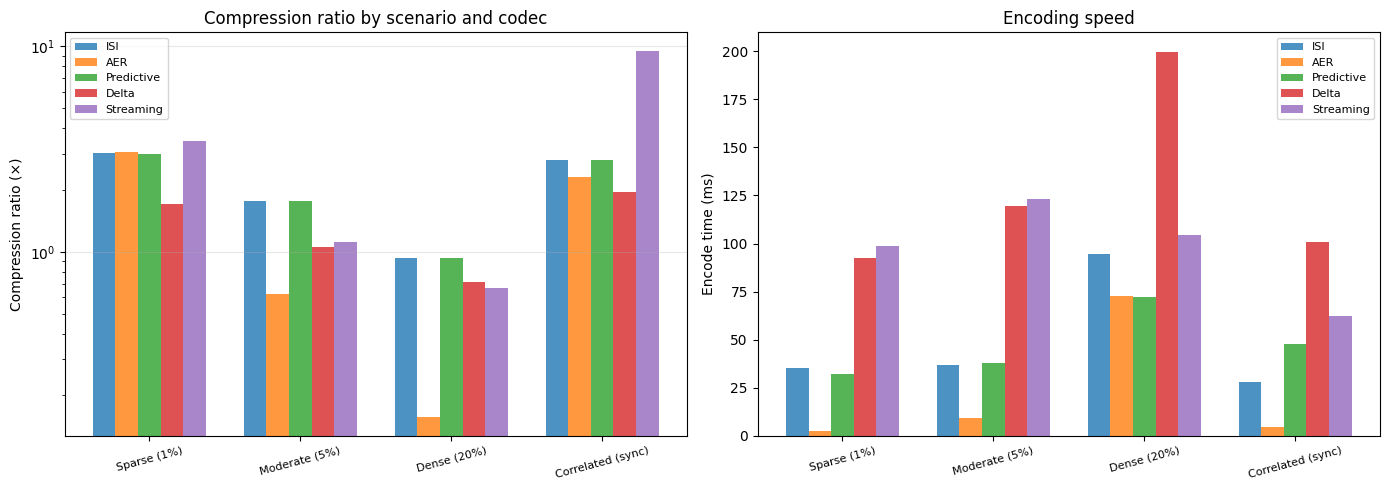

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Compression ratio bar chart
x = np.arange(len(scenarios))
width = 0.15
for i, (codec_name, _) in enumerate(codecs.items()):
    ratios = [results[s][codec_name]["ratio"] for s in scenarios]
    axes[0].bar(x + i * width, ratios, width, label=codec_name, alpha=0.8)

axes[0].set_xticks(x + width * 2)
axes[0].set_xticklabels(list(scenarios.keys()), rotation=15, fontsize=8)
axes[0].set_ylabel("Compression ratio (×)")
axes[0].set_title("Compression ratio by scenario and codec")
axes[0].legend(fontsize=8)
axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3, axis="y")

# Encode speed
for i, (codec_name, _) in enumerate(codecs.items()):
    speeds = [results[s][codec_name]["encode_ms"] for s in scenarios]
    axes[1].bar(x + i * width, speeds, width, label=codec_name, alpha=0.8)

axes[1].set_xticks(x + width * 2)
axes[1].set_xticklabels(list(scenarios.keys()), rotation=15, fontsize=8)
axes[1].set_ylabel("Encode time (ms)")
axes[1].set_title("Encoding speed")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 4. Compression Ratio vs Spike Density

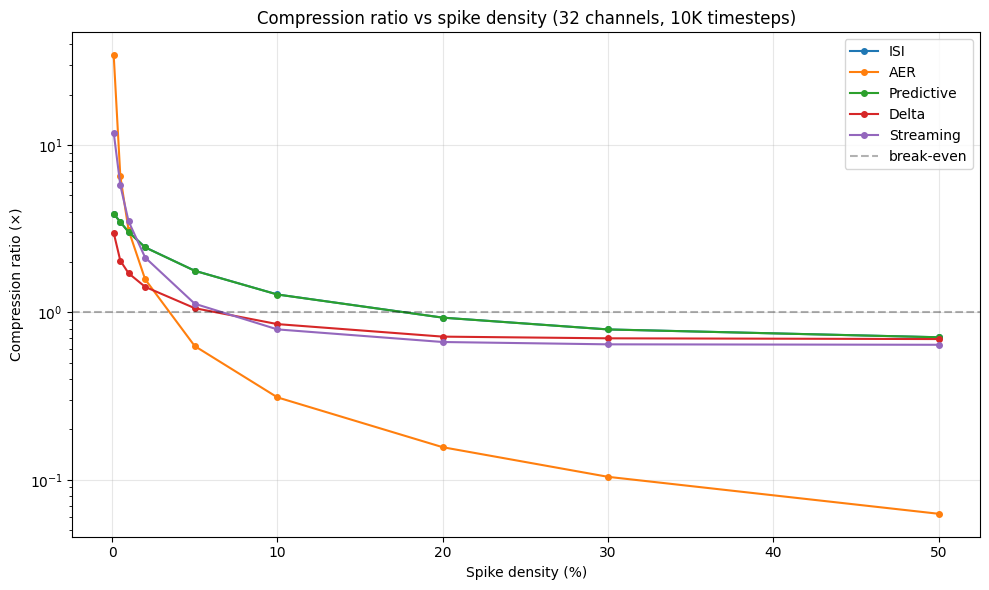

In [6]:
densities = [0.001, 0.005, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.5]
density_results = {c: [] for c in codecs}

for d in densities:
    data = (rng.random((N_CHANNELS, T)) < d).astype(np.uint8)
    raw_bytes = data.size // 8 + 1
    for codec_name, codec in codecs.items():
        compressed, _ = codec.compress(data)
        ratio = raw_bytes / max(len(compressed), 1)
        density_results[codec_name].append(ratio)

fig, ax = plt.subplots(figsize=(10, 6))
for codec_name in codecs:
    ax.semilogy([d * 100 for d in densities], density_results[codec_name],
                "o-", markersize=4, label=codec_name)
ax.axhline(1.0, color="black", linestyle="--", alpha=0.3, label="break-even")
ax.set_xlabel("Spike density (%)")
ax.set_ylabel("Compression ratio (×)")
ax.set_title("Compression ratio vs spike density (32 channels, 10K timesteps)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

| Codec | Principle | Strength | Weakness |
|-------|-----------|----------|----------|
| ISI | Encode inter-spike intervals | Best for regular spikers | Poor for bursts |
| AER | Address + delta timestamp | Best for multi-channel sparse | Overhead at high density |
| Predictive | EMA prediction + residual | Adapts to rate changes | Predictor lag |
| Delta | Spatial delta across channels | Best for correlated channels | No gain if independent |
| Streaming | Online block coding | Lowest latency | Lower ratio than offline |

At typical cortical densities (1-5%), all codecs achieve 10-100×
compression. AER dominates for multi-channel sparse data; ISI
is simplest for single-channel recording.

For hardware deployment, AER maps directly to `sc_aer_encoder.v`
in the HDL library.